In [1]:
%cd "C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4"

C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4


C:\Users\asmaa\PycharmProjects\pythonProject\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import torch

In [3]:
import devices
import utils
import samplers


In [4]:
save_folder_path = r"C:\Users\asmaa\Desktop\Amr\2nd Paper\Experiments"

In [5]:
# analytic_fields = np.load(save_folder_path + r"\Planar\Several Modes Weakly Guiding\analytic_fields.npy")
# DCNN_fields = np.load(save_folder_path + r"\Planar\Several Modes Weakly Guiding\DCNN_fields.npy")
# FCNN_fields = np.load(save_folder_path + r"\Planar\Several Modes Weakly Guiding\FCNN_fields.npy")
# FD_fields = np.load(save_folder_path + r"\Planar\Several Modes Weakly Guiding\FD_fields.npy")

analytic_fields = np.load(save_folder_path + r"\Planar\Several Modes Moderate Contrast\analytic_fields.npy")
DCNN_fields = np.load(save_folder_path + r"\Planar\Several Modes Moderate Contrast\DCNN_fields.npy")
# FCNN_fields = np.load(save_folder_path + r"\Planar\Several Modes Moderate Contrast\FCNN_fields.npy")
FD_fields = np.load(save_folder_path + r"\Planar\Several Modes Moderate Contrast\FD_fields.npy")
# 
# analytic_fields = np.load(save_folder_path + r"\Planar\Several Modes High Contrast\analytic_fields.npy")
# DCNN_fields = np.load(save_folder_path + r"\Planar\Several Modes High Contrast\DCNN_fields.npy")
# # FCNN_fields = np.load(save_folder_path + r"\Planar\Several Modes Moderate Contrast\FCNN_fields.npy")
# FD_fields = np.load(save_folder_path + r"\Planar\Several Modes High Contrast\FD_fields.npy")



FD_fields.shape

FD_fields.shape

(3, 279)

In [6]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd
dx = (lambd / 20) * k_0

# normalized simulation lengths
substrate_length = (6 * lambd) * k_0
core_length = (2 * lambd) * k_0
cladding_length = (6 * lambd) * k_0

# refractive indices
n_substrate = 1.44
n_core = 1.55
n_cladding = 1.44

# 
# # parameters
# lambd = 1
# 
# # wave number and normalized spacing
# k_0 = 2 * np.pi / lambd
# dx = (lambd / 40) * k_0
# 
# # normalized simulation lengths
# substrate_length = (4 * lambd) * k_0
# core_length = (1 * lambd) * k_0
# cladding_length = (4 * lambd) * k_0
# 
# # refractive indices
# n_substrate = 1
# n_core = 3
# n_cladding = 1

In [7]:
study = 'TM'
field_type = 'E'
dtype = torch.float64
memory_type = 'cpu'
RIs = [n_substrate, n_core, n_cladding]
lengths = [substrate_length, core_length, cladding_length]
reference_device = devices.SlabWaveguide(RIs, lambd, lengths, study=study, field_type=field_type)

In [8]:
x = samplers.uniform_grid(reference_device, dx, dtype, memory_type)[:, 0]/k_0

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
C:\Users\asmaa\AppData\Local\Temp\ipykernel_26164\682410546.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("$X(\mu m)$")


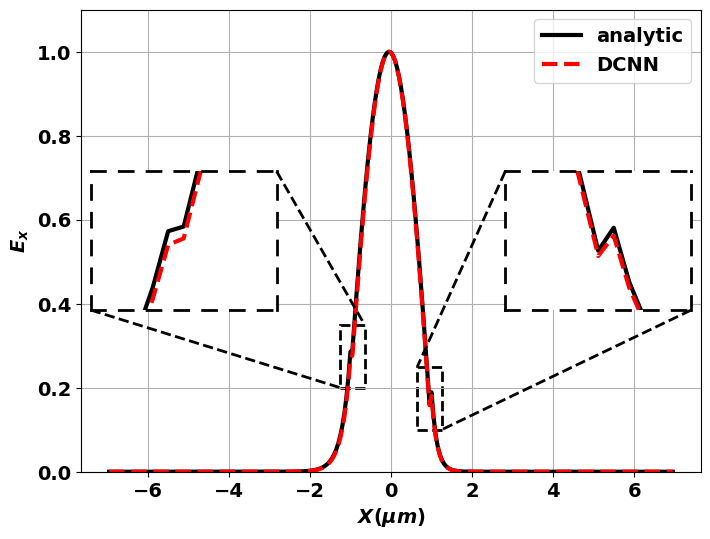

In [23]:
font = {
    'weight' : 'bold',
    'size' : 14
    }

matplotlib.rc('font', **font)
y_1 = analytic_fields[0]
y_2 = -DCNN_fields[0]

# Create the main plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(x, y_1, label="analytic", color='black', linewidth=3)
ax.plot(x, y_2, label="DCNN", color='red', linewidth=3, linestyle='--')
ax.grid(True)
ax.set_ylim([0, 1.1])
ax.set_xlabel("$X(\mu m)$")
ax.set_ylabel("$E_{x}$")
ax.legend()

# Create an inset zoomed-in axes
axins = inset_axes(ax, width="30%", height="30%", loc="right")  # Adjust size and position
axins.plot(x, y_1, label="analytic", color='black', linewidth=3)
axins.plot(x, y_2, label="DCNN", color='red', linewidth=3, linestyle='--')

for spine in axins.spines.values():
  spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
  spine.set(linewidth=2)

# Define zoom region
x1, x2, y1, y2 = 0.65, 1.25, 0.1, 0.25  # Zoom-in limits
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Remove ticks on inset
axins.set_xticks([])
axins.set_yticks([])
axins.grid(True);

# Create an inset zoomed-in axes
axins2 = inset_axes(ax, width="30%", height="30%", loc="center left")  # Adjust size and position
axins2.plot(x, y_1, label="analytic", color='black', linewidth=3)
axins2.plot(x, y_2, label="DCNN", color='red', linewidth=3, linestyle='--')

for spine in axins2.spines.values():
  spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
  spine.set(linewidth=2)

# Define zoom region
x1, x2, y1, y2 = -1.25, -0.65, 0.2, 0.35  # Zoom-in limits
axins2.set_xlim(x1, x2)
axins2.set_ylim(y1, y2)

# Remove ticks on inset
axins2.set_xticks([])
axins2.set_yticks([])
axins2.grid(True);

# Mark zoomed area on the main plot
mark_inset(ax, axins, loc1=4, loc2=2, fc="none", ec="black", lw=2, linestyle='dashed')
mark_inset(ax, axins2, loc1=3, loc2=1, fc="none", ec="black", lw=2, linestyle='dashed')

plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:74: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:74: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\m'
C:\Users\asmaa\AppData\Local\Temp\ipykernel_26164\614785360.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_xlabel("$X(\mu m)$")
C:\Users\asmaa\AppData\Local\Temp\ipykernel_26164\614785360.py:74: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_xlabel("$X(\mu m)$")
C:\Users\asmaa\AppData\Local\Temp\ipykernel_26164\614785360.py:130: SyntaxWarning: invalid escape sequence '\m'
  ax[2].set_xlabel("$X(\mu m)$")


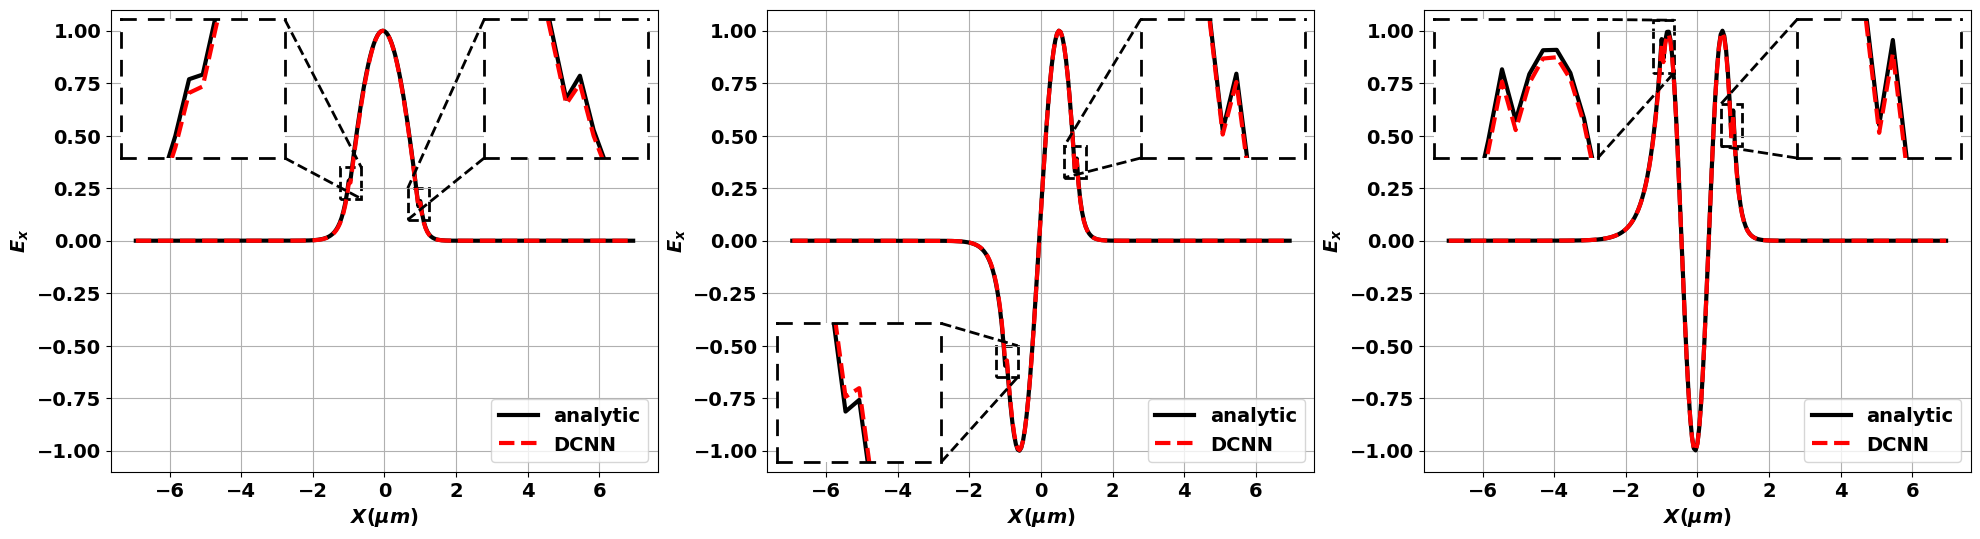

In [36]:
font = {
    'weight' : 'bold',
    'size' : 14
    }

matplotlib.rc('font', **font)
y_1 = analytic_fields[0]
y_2 = -DCNN_fields[0]

# Create the main plot
fig, ax = plt.subplots(1, 3, figsize=(24, 6))
ax[0].plot(x, y_1, label="analytic", color='black', linewidth=3)
ax[0].plot(x, y_2, label="DCNN", color='red', linewidth=3, linestyle='--')
ax[0].grid(True)
ax[0].set_ylim([-1.1, 1.1])
ax[0].set_xlabel("$X(\mu m)$")
ax[0].set_ylabel("$E_{x}$")
ax[0].legend()

# Create an inset zoomed-in axes
axins = inset_axes(ax[0], width="30%", height="30%", loc="upper right")  # Adjust size and position
axins.plot(x, y_1, label="analytic", color='black', linewidth=3)
axins.plot(x, y_2, label="DCNN", color='red', linewidth=3, linestyle='--')

for spine in axins.spines.values():
  spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
  spine.set(linewidth=2)

# Define zoom region
x1, x2, y1, y2 = 0.65, 1.25, 0.1, 0.25  # Zoom-in limits
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Remove ticks on inset
axins.set_xticks([])
axins.set_yticks([])
axins.grid(True);

# Create an inset zoomed-in axes
axins2 = inset_axes(ax[0], width="30%", height="30%", loc="upper left")  # Adjust size and position
axins2.plot(x, y_1, label="analytic", color='black', linewidth=3)
axins2.plot(x, y_2, label="DCNN", color='red', linewidth=3, linestyle='--')

for spine in axins2.spines.values():
  spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
  spine.set(linewidth=2)

# Define zoom region
x1, x2, y1, y2 = -1.25, -0.65, 0.2, 0.35  # Zoom-in limits
axins2.set_xlim(x1, x2)
axins2.set_ylim(y1, y2)

# Remove ticks on inset
axins2.set_xticks([])
axins2.set_yticks([])
axins2.grid(True);

# Mark zoomed area on the main plot
mark_inset(ax[0], axins, loc1=2, loc2=3, fc="none", ec="black", lw=2, linestyle='dashed')
mark_inset(ax[0], axins2, loc1=4, loc2=1, fc="none", ec="black", lw=2, linestyle='dashed')
ax[0].legend(loc='lower right')


##############################################################

y_1 = -analytic_fields[1]
y_2 = DCNN_fields[1]

# Create the main plot
ax[1].plot(x, y_1, label="analytic", color='black', linewidth=3)
ax[1].plot(x, y_2, label="DCNN", color='red', linewidth=3, linestyle='--')
ax[1].grid(True)
ax[1].set_ylim([-1.1, 1.1])
ax[1].set_xlabel("$X(\mu m)$")
ax[1].set_ylabel("$E_{x}$")
ax[1].legend()

# Create an inset zoomed-in axes
axins = inset_axes(ax[1], width="30%", height="30%", loc="upper right")  # Adjust size and position
axins.plot(x, y_1, label="analytic", color='black', linewidth=3)
axins.plot(x, y_2, label="DCNN", color='red', linewidth=3, linestyle='--')

for spine in axins.spines.values():
  spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
  spine.set(linewidth=2)

# Define zoom region
x1, x2, y1, y2 = 0.65, 1.25, 0.3, 0.45  # Zoom-in limits
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Remove ticks on inset
axins.set_xticks([])
axins.set_yticks([])
axins.grid(True);

# Create an inset zoomed-in axes
axins2 = inset_axes(ax[1], width="30%", height="30%", loc="lower left")  # Adjust size and position
axins2.plot(x, y_1, label="analytic", color='black', linewidth=3)
axins2.plot(x, y_2, label="DCNN", color='red', linewidth=3, linestyle='--')

for spine in axins2.spines.values():
  spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
  spine.set(linewidth=2)

# Define zoom region
x1, x2, y1, y2 = -1.25, -0.65, -0.65, -0.5  # Zoom-in limits
axins2.set_xlim(x1, x2)
axins2.set_ylim(y1, y2)

# Remove ticks on inset
axins2.set_xticks([])
axins2.set_yticks([])
axins2.grid(True);

# Mark zoomed area on the main plot
mark_inset(ax[1], axins, loc1=2, loc2=3, fc="none", ec="black", lw=2, linestyle='dashed')
mark_inset(ax[1], axins2, loc1=4, loc2=1, fc="none", ec="black", lw=2, linestyle='dashed')
ax[1].legend(loc='lower right')

##################################################
y_1 = analytic_fields[2]
y_2 = DCNN_fields[2]

# Create the main plot
ax[2].plot(x, y_1, label="analytic", color='black', linewidth=3)
ax[2].plot(x, y_2, label="DCNN", color='red', linewidth=3, linestyle='--')
ax[2].grid(True)
ax[2].set_ylim([-1.1, 1.1])
ax[2].set_xlabel("$X(\mu m)$")
ax[2].set_ylabel("$E_{x}$")
ax[2].legend()

# Create an inset zoomed-in axes
axins = inset_axes(ax[2], width="30%", height="30%", loc="upper right")  # Adjust size and position
axins.plot(x, y_1, label="analytic", color='black', linewidth=3)
axins.plot(x, y_2, label="DCNN", color='red', linewidth=3, linestyle='--')

for spine in axins.spines.values():
  spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
  spine.set(linewidth=2)

# Define zoom region
x1, x2, y1, y2 = 0.65, 1.25, 0.45, 0.65  # Zoom-in limits
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Remove ticks on inset
axins.set_xticks([])
axins.set_yticks([])
axins.grid(True);

# Create an inset zoomed-in axes
axins2 = inset_axes(ax[2], width="30%", height="30%", loc="upper left")  # Adjust size and position
axins2.plot(x, y_1, label="analytic", color='black', linewidth=3)
axins2.plot(x, y_2, label="DCNN", color='red', linewidth=3, linestyle='--')

for spine in axins2.spines.values():
  spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
  spine.set(linewidth=2)

# Define zoom region
x1, x2, y1, y2 = -1.25, -0.65, 0.8, 1.05  # Zoom-in limits
axins2.set_xlim(x1, x2)
axins2.set_ylim(y1, y2)

# Remove ticks on inset
axins2.set_xticks([])
axins2.set_yticks([])
axins2.grid(True);

# Mark zoomed area on the main plot
mark_inset(ax[2], axins, loc1=2, loc2=3, fc="none", ec="black", lw=2, linestyle='dashed')
mark_inset(ax[2], axins2, loc1=1, loc2=4, fc="none", ec="black", lw=2, linestyle='dashed')
ax[2].legend(loc='lower right')


plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:74: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:74: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\m'
C:\Users\asmaa\AppData\Local\Temp\ipykernel_23820\1410095617.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_xlabel("$X(\mu m)$")
C:\Users\asmaa\AppData\Local\Temp\ipykernel_23820\1410095617.py:74: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_xlabel("$X(\mu m)$")
C:\Users\asmaa\AppData\Local\Temp\ipykernel_23820\1410095617.py:130: SyntaxWarning: invalid escape sequence '\m'
  ax[2].set_xlabel("$X(\mu m)$")


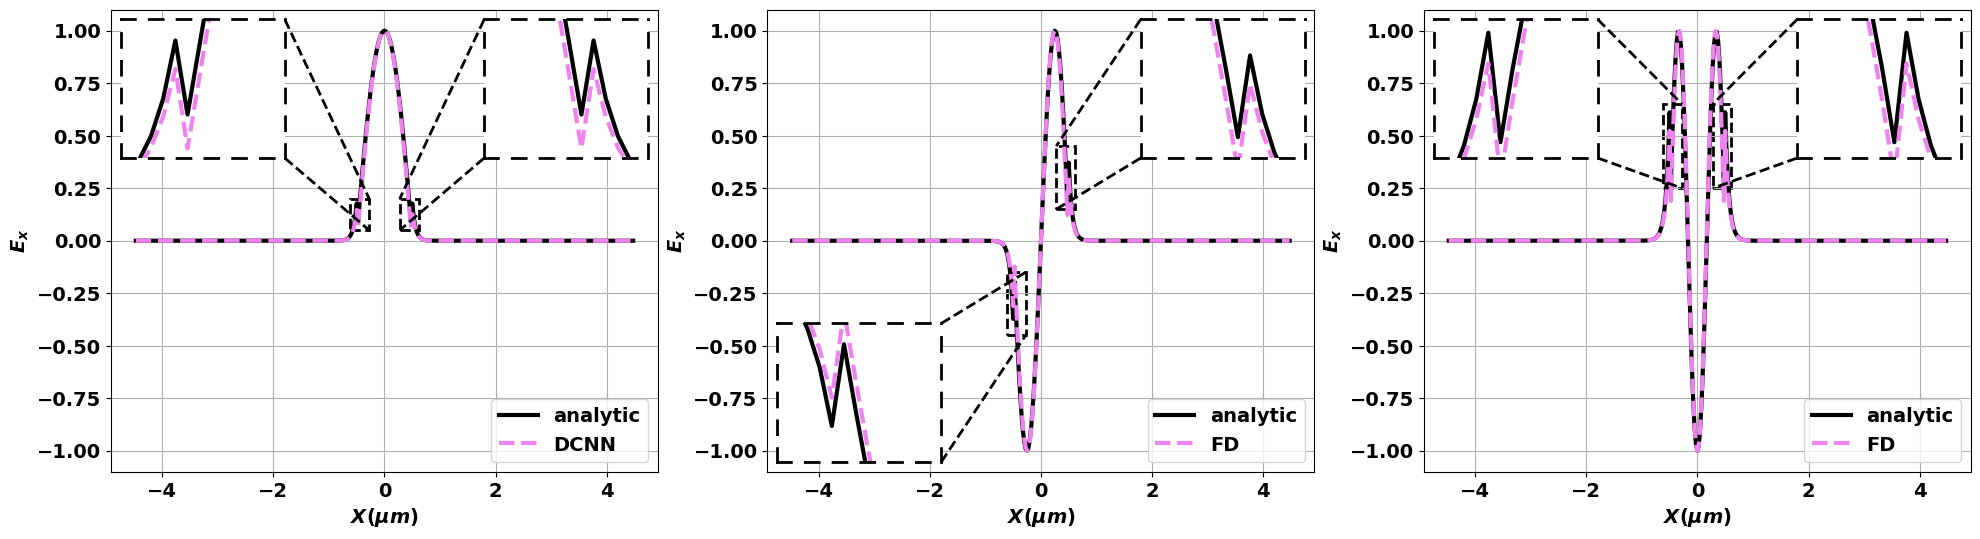

In [254]:
font = {
    'weight' : 'bold',
    'size' : 14
    }

matplotlib.rc('font', **font)
y_1 = analytic_fields[0]
y_2 = -FD_fields[0]

# Create the main plot
fig, ax = plt.subplots(1, 3, figsize=(24, 6))
ax[0].plot(x, y_1, label="analytic", color='black', linewidth=3)
ax[0].plot(x, y_2, label="DCNN", color='violet', linewidth=3, linestyle='--')
ax[0].grid(True)
ax[0].set_ylim([-1.1, 1.1])
ax[0].set_xlabel("$X(\mu m)$")
ax[0].set_ylabel("$E_{x}$")
ax[0].legend()

# Create an inset zoomed-in axes
axins = inset_axes(ax[0], width="30%", height="30%", loc="upper right")  # Adjust size and position
axins.plot(x, y_1, label="analytic", color='black', linewidth=3)
axins.plot(x, y_2, label="DCNN", color='violet', linewidth=3, linestyle='--')

for spine in axins.spines.values():
  spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
  spine.set(linewidth=2)

# Define zoom region
x1, x2, y1, y2 = 0.275, 0.6125, 0.05, 0.2  # Zoom-in limits
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Remove ticks on inset
axins.set_xticks([])
axins.set_yticks([])
axins.grid(True);

# Create an inset zoomed-in axes
axins2 = inset_axes(ax[0], width="30%", height="30%", loc="upper left")  # Adjust size and position
axins2.plot(x, y_1, label="analytic", color='black', linewidth=3)
axins2.plot(x, y_2, label="DCNN", color='violet', linewidth=3, linestyle='--')

for spine in axins2.spines.values():
  spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
  spine.set(linewidth=2)

# Define zoom region
x1, x2, y1, y2 = -0.6125, -0.275, 0.05, 0.2 # Zoom-in limits
axins2.set_xlim(x1, x2)
axins2.set_ylim(y1, y2)

# Remove ticks on inset
axins2.set_xticks([])
axins2.set_yticks([])
axins2.grid(True);

# Mark zoomed area on the main plot
mark_inset(ax[0], axins, loc1=2, loc2=3, fc="none", ec="black", lw=2, linestyle='dashed')
mark_inset(ax[0], axins2, loc1=4, loc2=1, fc="none", ec="black", lw=2, linestyle='dashed')
ax[0].legend(loc='lower right')


##############################################################

y_1 = -analytic_fields[1]
y_2 = -FD_fields[1]

# Create the main plot
ax[1].plot(x, y_1, label="analytic", color='black', linewidth=3)
ax[1].plot(x, y_2, label="FD", color='violet', linewidth=3, linestyle='--')
ax[1].grid(True)
ax[1].set_ylim([-1.1, 1.1])
ax[1].set_xlabel("$X(\mu m)$")
ax[1].set_ylabel("$E_{x}$")
ax[1].legend()

# Create an inset zoomed-in axes
axins = inset_axes(ax[1], width="30%", height="30%", loc="upper right")  # Adjust size and position
axins.plot(x, y_1, label="analytic", color='black', linewidth=3)
axins.plot(x, y_2, label="DCNN", color='violet', linewidth=3, linestyle='--')

for spine in axins.spines.values():
  spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
  spine.set(linewidth=2)

# Define zoom region
x1, x2, y1, y2 = 0.275, 0.6125, 0.15, 0.45  # Zoom-in limits
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Remove ticks on inset
axins.set_xticks([])
axins.set_yticks([])
axins.grid(True);

# Create an inset zoomed-in axes
axins2 = inset_axes(ax[1], width="30%", height="30%", loc="lower left")  # Adjust size and position
axins2.plot(x, y_1, label="analytic", color='black', linewidth=3)
axins2.plot(x, y_2, label="DCNN", color='violet', linewidth=3, linestyle='--')

for spine in axins2.spines.values():
  spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
  spine.set(linewidth=2)

# Define zoom region
x1, x2, y1, y2 = -0.6125, -0.275, -0.45, -0.15  # Zoom-in limits
axins2.set_xlim(x1, x2)
axins2.set_ylim(y1, y2)

# Remove ticks on inset
axins2.set_xticks([])
axins2.set_yticks([])
axins2.grid(True);

# Mark zoomed area on the main plot
mark_inset(ax[1], axins, loc1=2, loc2=3, fc="none", ec="black", lw=2, linestyle='dashed')
mark_inset(ax[1], axins2, loc1=4, loc2=1, fc="none", ec="black", lw=2, linestyle='dashed')
ax[1].legend(loc='lower right')

##################################################
y_1 = analytic_fields[2]
y_2 = -FD_fields[2]

# Create the main plot
ax[2].plot(x, y_1, label="analytic", color='black', linewidth=3)
ax[2].plot(x, y_2, label="FD", color='violet', linewidth=3, linestyle='--')
ax[2].grid(True)
ax[2].set_ylim([-1.1, 1.1])
ax[2].set_xlabel("$X(\mu m)$")
ax[2].set_ylabel("$E_{x}$")
ax[2].legend()

# Create an inset zoomed-in axes
axins = inset_axes(ax[2], width="30%", height="30%", loc="upper right")  # Adjust size and position
axins.plot(x, y_1, label="analytic", color='black', linewidth=3)
axins.plot(x, y_2, label="FD", color='violet', linewidth=3, linestyle='--')

for spine in axins.spines.values():
  spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
  spine.set(linewidth=2)

# Define zoom region
x1, x2, y1, y2 = 0.275, 0.6125, 0.25, 0.65  # Zoom-in limits
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Remove ticks on inset
axins.set_xticks([])
axins.set_yticks([])
axins.grid(True);

# Create an inset zoomed-in axes
axins2 = inset_axes(ax[2], width="30%", height="30%", loc="upper left")  # Adjust size and position
axins2.plot(x, y_1, label="analytic", color='black', linewidth=3)
axins2.plot(x, y_2, label="FD", color='violet', linewidth=3, linestyle='--')

for spine in axins2.spines.values():
  spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
  spine.set(linewidth=2)

# Define zoom region
x1, x2, y1, y2 = -0.6125, -0.275, 0.25, 0.65  # Zoom-in limits
axins2.set_xlim(x1, x2)
axins2.set_ylim(y1, y2)

# Remove ticks on inset
axins2.set_xticks([])
axins2.set_yticks([])
axins2.grid(True);

# Mark zoomed area on the main plot
mark_inset(ax[2], axins, loc1=2, loc2=3, fc="none", ec="black", lw=2, linestyle='dashed')
mark_inset(ax[2], axins2, loc1=1, loc2=4, fc="none", ec="black", lw=2, linestyle='dashed')
ax[2].legend(loc='lower right')


plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:74: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:74: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\m'
C:\Users\asmaa\AppData\Local\Temp\ipykernel_23820\237339367.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_xlabel("$X(\mu m)$")
C:\Users\asmaa\AppData\Local\Temp\ipykernel_23820\237339367.py:74: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_xlabel("$X(\mu m)$")
C:\Users\asmaa\AppData\Local\Temp\ipykernel_23820\237339367.py:130: SyntaxWarning: invalid escape sequence '\m'
  ax[2].set_xlabel("$X(\mu m)$")


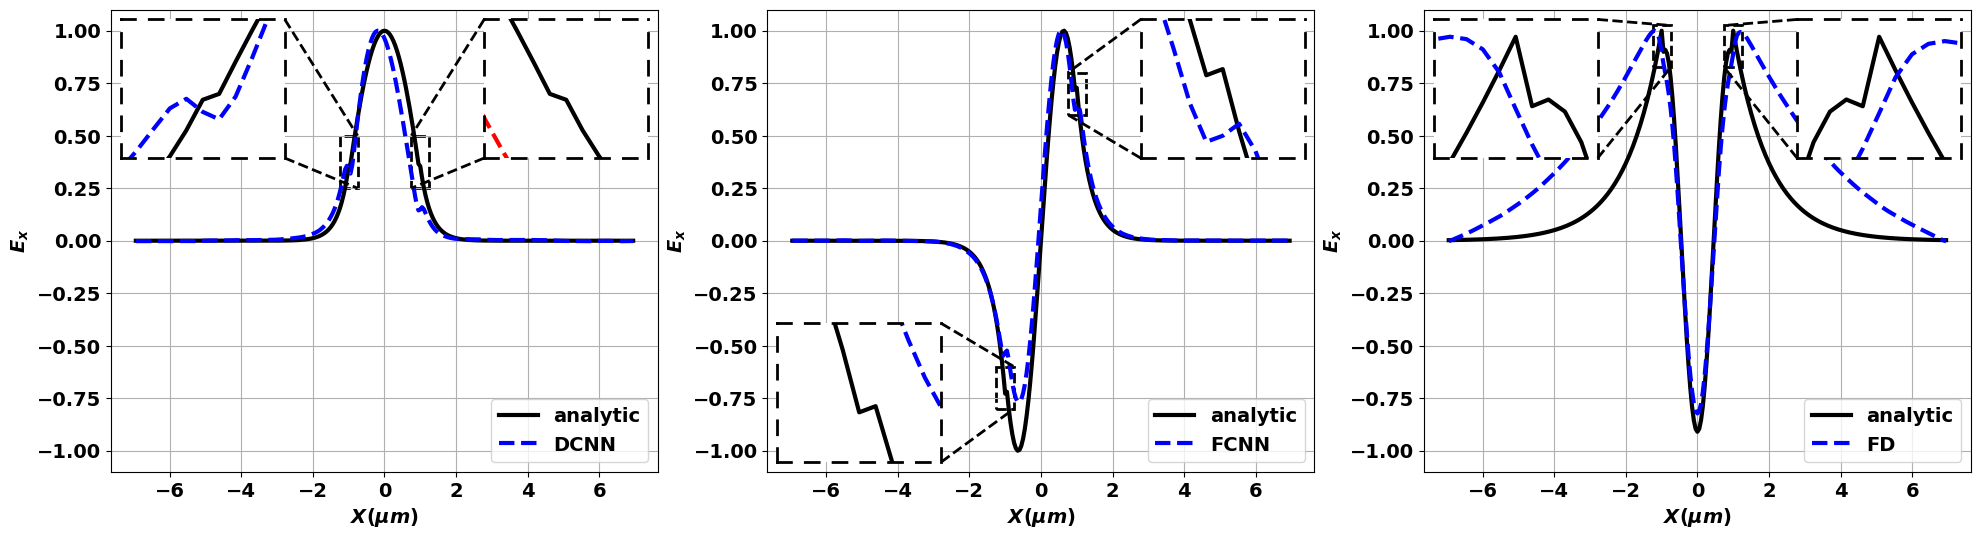

In [174]:
# font = {
#     'weight' : 'bold',
#     'size' : 14
#     }
# 
# matplotlib.rc('font', **font)
# y_1 = analytic_fields[0]
# y_2 = -FCNN_fields[0]
# 
# # Create the main plot
# fig, ax = plt.subplots(1, 3, figsize=(24, 6))
# ax[0].plot(x, y_1, label="analytic", color='black', linewidth=3)
# ax[0].plot(x, y_2, label="DCNN", color='blue', linewidth=3, linestyle='--')
# ax[0].grid(True)
# ax[0].set_ylim([-1.1, 1.1])
# ax[0].set_xlabel("$X(\mu m)$")
# ax[0].set_ylabel("$E_{x}$")
# ax[0].legend()
# 
# # Create an inset zoomed-in axes
# axins = inset_axes(ax[0], width="30%", height="30%", loc="upper right")  # Adjust size and position
# axins.plot(x, y_1, label="analytic", color='black', linewidth=3)
# axins.plot(x, y_2, label="FCNN", color='red', linewidth=3, linestyle='--')
# 
# for spine in axins.spines.values():
#   spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
#   spine.set(linewidth=2)
# 
# # Define zoom region
# x1, x2, y1, y2 = 0.75, 1.25, 0.25, 0.5  # Zoom-in limits
# axins.set_xlim(x1, x2)
# axins.set_ylim(y1, y2)
# 
# # Remove ticks on inset
# axins.set_xticks([])
# axins.set_yticks([])
# axins.grid(True);
# 
# # Create an inset zoomed-in axes
# axins2 = inset_axes(ax[0], width="30%", height="30%", loc="upper left")  # Adjust size and position
# axins2.plot(x, y_1, label="analytic", color='black', linewidth=3)
# axins2.plot(x, y_2, label="FCNN", color='blue', linewidth=3, linestyle='--')
# 
# for spine in axins2.spines.values():
#   spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
#   spine.set(linewidth=2)
# 
# # Define zoom region
# x1, x2, y1, y2 = -1.25, -0.75, 0.25, 0.5  # Zoom-in limits
# axins2.set_xlim(x1, x2)
# axins2.set_ylim(y1, y2)
# 
# # Remove ticks on inset
# axins2.set_xticks([])
# axins2.set_yticks([])
# axins2.grid(True);
# 
# # Mark zoomed area on the main plot
# mark_inset(ax[0], axins, loc1=2, loc2=3, fc="none", ec="black", lw=2, linestyle='dashed')
# mark_inset(ax[0], axins2, loc1=4, loc2=1, fc="none", ec="black", lw=2, linestyle='dashed')
# ax[0].legend(loc='lower right')
# 
# 
# ##############################################################
# 
# y_1 = -analytic_fields[1]
# y_2 = FCNN_fields[1]
# 
# # Create the main plot
# ax[1].plot(x, y_1, label="analytic", color='black', linewidth=3)
# ax[1].plot(x, y_2, label="FCNN", color='blue', linewidth=3, linestyle='--')
# ax[1].grid(True)
# ax[1].set_ylim([-1.1, 1.1])
# ax[1].set_xlabel("$X(\mu m)$")
# ax[1].set_ylabel("$E_{x}$")
# ax[1].legend()
# 
# # Create an inset zoomed-in axes
# axins = inset_axes(ax[1], width="30%", height="30%", loc="upper right")  # Adjust size and position
# axins.plot(x, y_1, label="analytic", color='black', linewidth=3)
# axins.plot(x, y_2, label="FCNN", color='blue', linewidth=3, linestyle='--')
# 
# for spine in axins.spines.values():
#   spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
#   spine.set(linewidth=2)
# 
# # Define zoom region
# x1, x2, y1, y2 = 0.75, 1.25, 0.6, 0.8  # Zoom-in limits
# axins.set_xlim(x1, x2)
# axins.set_ylim(y1, y2)
# 
# # Remove ticks on inset
# axins.set_xticks([])
# axins.set_yticks([])
# axins.grid(True);
# 
# # Create an inset zoomed-in axes
# axins2 = inset_axes(ax[1], width="30%", height="30%", loc="lower left")  # Adjust size and position
# axins2.plot(x, y_1, label="analytic", color='black', linewidth=3)
# axins2.plot(x, y_2, label="FCNN", color='blue', linewidth=3, linestyle='--')
# 
# for spine in axins2.spines.values():
#   spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
#   spine.set(linewidth=2)
# 
# # Define zoom region
# x1, x2, y1, y2 = -1.25, -0.75, -0.8, -0.6  # Zoom-in limits
# axins2.set_xlim(x1, x2)
# axins2.set_ylim(y1, y2)
# 
# # Remove ticks on inset
# axins2.set_xticks([])
# axins2.set_yticks([])
# axins2.grid(True);
# 
# # Mark zoomed area on the main plot
# mark_inset(ax[1], axins, loc1=2, loc2=3, fc="none", ec="black", lw=2, linestyle='dashed')
# mark_inset(ax[1], axins2, loc1=4, loc2=1, fc="none", ec="black", lw=2, linestyle='dashed')
# ax[1].legend(loc='lower right')
# 
# ##################################################
# y_1 = analytic_fields[2]
# y_2 = -FCNN_fields[2]
# 
# # Create the main plot
# ax[2].plot(x, y_1, label="analytic", color='black', linewidth=3)
# ax[2].plot(x, y_2, label="FD", color='blue', linewidth=3, linestyle='--')
# ax[2].grid(True)
# ax[2].set_ylim([-1.1, 1.1])
# ax[2].set_xlabel("$X(\mu m)$")
# ax[2].set_ylabel("$E_{x}$")
# ax[2].legend()
# 
# # Create an inset zoomed-in axes
# axins = inset_axes(ax[2], width="30%", height="30%", loc="upper right")  # Adjust size and position
# axins.plot(x, y_1, label="analytic", color='black', linewidth=3)
# axins.plot(x, y_2, label="FD", color='blue', linewidth=3, linestyle='--')
# 
# for spine in axins.spines.values():
#   spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
#   spine.set(linewidth=2)
# 
# # Define zoom region
# x1, x2, y1, y2 = 0.75, 1.25, 0.825, 1.025  # Zoom-in limits
# axins.set_xlim(x1, x2)
# axins.set_ylim(y1, y2)
# 
# # Remove ticks on inset
# axins.set_xticks([])
# axins.set_yticks([])
# axins.grid(True);
# 
# # Create an inset zoomed-in axes
# axins2 = inset_axes(ax[2], width="30%", height="30%", loc="upper left")  # Adjust size and position
# axins2.plot(x, y_1, label="analytic", color='black', linewidth=3)
# axins2.plot(x, y_2, label="FCNN", color='blue', linewidth=3, linestyle='--')
# 
# for spine in axins2.spines.values():
#   spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
#   spine.set(linewidth=2)
# 
# # Define zoom region
# x1, x2, y1, y2 = -1.25, -0.75, 0.825, 1.025  # Zoom-in limits
# axins2.set_xlim(x1, x2)
# axins2.set_ylim(y1, y2)
# 
# # Remove ticks on inset
# axins2.set_xticks([])
# axins2.set_yticks([])
# axins2.grid(True);
# 
# # Mark zoomed area on the main plot
# mark_inset(ax[2], axins, loc1=2, loc2=3, fc="none", ec="black", lw=2, linestyle='dashed')
# mark_inset(ax[2], axins2, loc1=1, loc2=4, fc="none", ec="black", lw=2, linestyle='dashed')
# ax[2].legend(loc='lower right')
# 
# 
# plt.show()